In [39]:
import pandas as pd
from arch import arch_model
import ccxt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

In [7]:
def fetch_data():
    exchange = ccxt.binance()
    symbol = 'BTC/USDT'
    timeframe = '1h'
    limit = 30
    data = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(data, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df
    

In [29]:
df = fetch_data()

In [33]:
def get_returns(df):
    df['returns'] = df['close'].pct_change().dropna()
    ndf = df['returns'].dropna()
    
    return ndf

In [34]:
plotting_data = get_returns(df)

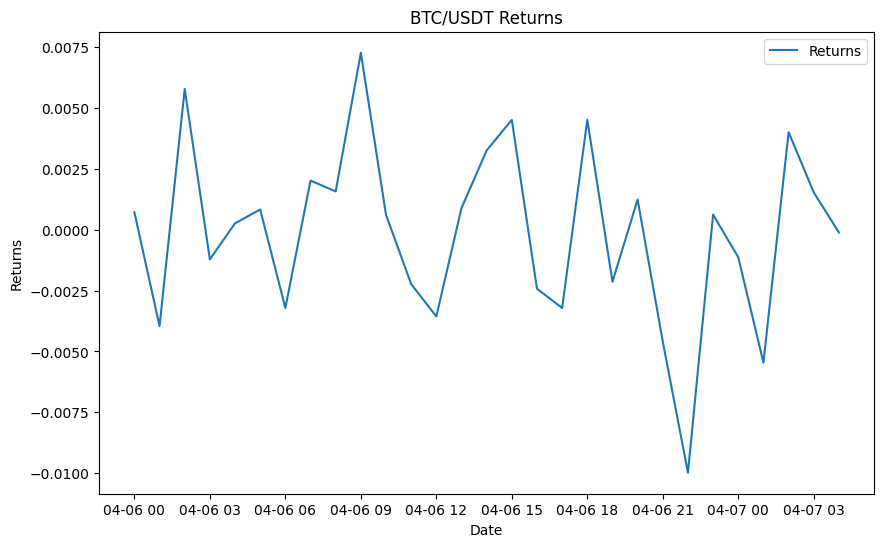

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plotting_data, label='Returns')
ax.set_title('BTC/USDT Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

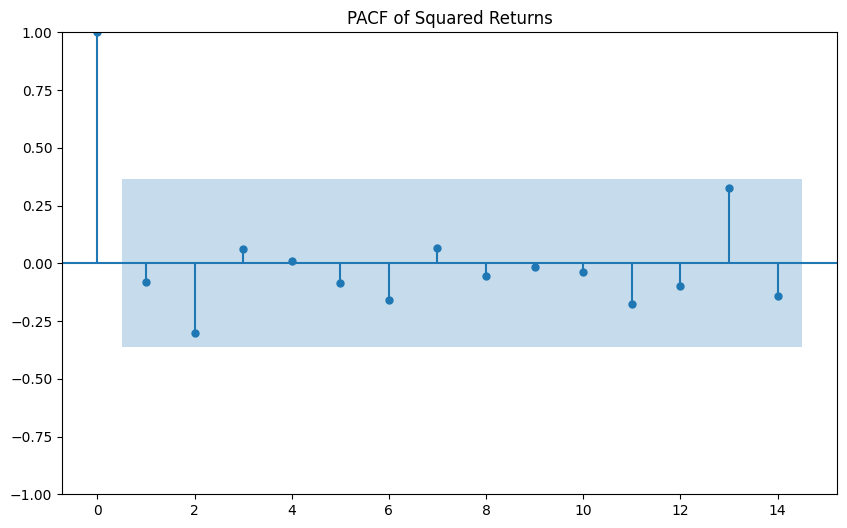

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(plotting_data**2, ax=ax)
ax.set_title('PACF of Squared Returns')
plt.show()

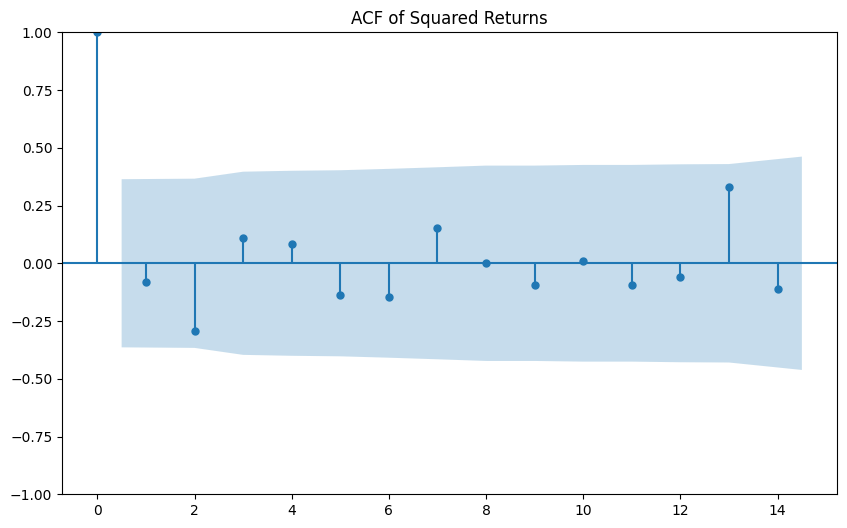

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(plotting_data**2, ax=ax)
ax.set_title('ACF of Squared Returns')
plt.show()

In [41]:
cutoff = 0.8
train_size = int(len(plotting_data) * cutoff)
train_data = plotting_data[:train_size]
test_data = plotting_data[train_size:]

In [43]:
model = arch_model(train_data, vol='Garch', p=1, q=1, rescale=False)
model_fit = model.fit(disp='off')
print(model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                95.4987
Distribution:                  Normal   AIC:                          -182.997
Method:            Maximum Likelihood   BIC:                          -178.455
                                        No. Observations:                   23
Date:                Tue, Apr 07 2026   Df Residuals:                       22
Time:                        05:43:51   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -9.0322e-05  2.872e-05     -3.144  1.6

In [ ]:
import os
import json
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Fit final model on train split
model = arch_model(train_data * 100, vol='Garch', p=1, q=1, rescale=False)
model_fit = model.fit(disp='off')
print(model_fit.summary())

# 2) Forecast variance over test horizon
h = len(test_data)
fc = model_fit.forecast(horizon=h, reindex=False)

# arch returns variance in percent-squared because we fit on returns*100.
# Convert back to variance of raw returns.
pred_var = (fc.variance.values[-1, :] / (100 ** 2)).astype(float)
pred_vol = np.sqrt(np.maximum(pred_var, 0.0))

# 3) Build a realized-volatility proxy from absolute returns
realized_vol = test_data.abs().to_numpy()

# Guard against length mismatch in edge cases
n = min(len(pred_vol), len(realized_vol))
pred_vol = pred_vol[:n]
realized_vol = realized_vol[:n]

mae = mean_absolute_error(realized_vol, pred_vol)
rmse = mean_squared_error(realized_vol, pred_vol) ** 0.5

# QLIKE loss for volatility forecasts
eps = 1e-12
rv2 = np.maximum(realized_vol ** 2, eps)
pv2 = np.maximum(pred_vol ** 2, eps)
qlike = float(np.mean(np.log(pv2) + (rv2 / pv2)))

metrics = {
    'horizon': int(n),
    'mae': float(mae),
    'rmse': float(rmse),
    'qlike': qlike,
}
print('Evaluation metrics:')
print(json.dumps(metrics, indent=2))

# 4) Persist trained model artifact into model directory
model_dir = Path('model')
model_dir.mkdir(parents=True, exist_ok=True)
artifact_path = model_dir / 'garch_btcusdt_1h.pkl'

with open(artifact_path, 'wb') as f:
    import pickle
    pickle.dump(model_fit, f)

print(f'Model saved to: {artifact_path.resolve()}')

In [ ]:
# Compare predicted vs realized volatility on test window
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pred_vol, label='Predicted Volatility (GARCH)', linewidth=2)
ax.plot(realized_vol, label='Realized Proxy |returns|', linewidth=1.5, alpha=0.8)
ax.set_title('Predicted vs Realized Volatility (Test Set)')
ax.set_xlabel('Test Step')
ax.set_ylabel('Volatility')
ax.legend()
plt.show()